#### 1.Imports

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### 2. Define Compounds

In [2]:
compounds = ["water", "ethanol", "methanol", "isopropanol",
    "acetone", "ethyl acetate",
    "benzene", "toluene", "chloroform", "hexane",
    "dimethylformamide", "acetonitrile" ]
data = []

#### 3. Fetch Data from API

In [3]:
data = []

for compound in compounds:
    try:
        url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{compound}/property/MolecularWeight,XLogP/JSON"
        
        response = requests.get(url)
        result = response.json()
        
        props = result['PropertyTable']['Properties'][0]
        props["name"] = compound
        
        data.append(props)
    
    except Exception as e:
        print(f"Error with {compound}: {e}")

df = pd.DataFrame(data)


#### 4. Data Cleaning & Selection

In [4]:
df = df[["name", "MolecularWeight", "XLogP"]]
df = df.dropna()

print(df)

                 name MolecularWeight  XLogP
0               water          18.015   -0.5
1             ethanol           46.07   -0.1
2            methanol          32.042   -0.5
3         isopropanol           60.10    0.3
4             acetone           58.08   -0.1
5       ethyl acetate           88.11    0.7
6             benzene           78.11    2.1
7             toluene           92.14    2.7
8          chloroform          119.37    2.3
9              hexane           86.18    3.9
10  dimethylformamide           73.09   -1.0
11       acetonitrile           41.05    0.0


#### 5. Add Sustainability Labels

In [5]:
green_solvents = ["water", "ethanol", "methanol"]
bio_based = ["ethanol", "methanol"]

df["is_green"] = df["name"].apply(lambda x: 1 if x in green_solvents else 0)
df["is_bio_based"] = df["name"].apply(lambda x: 1 if x in bio_based else 0)

print(df)

                 name MolecularWeight  XLogP  is_green  is_bio_based
0               water          18.015   -0.5         1             0
1             ethanol           46.07   -0.1         1             1
2            methanol          32.042   -0.5         1             1
3         isopropanol           60.10    0.3         0             0
4             acetone           58.08   -0.1         0             0
5       ethyl acetate           88.11    0.7         0             0
6             benzene           78.11    2.1         0             0
7             toluene           92.14    2.7         0             0
8          chloroform          119.37    2.3         0             0
9              hexane           86.18    3.9         0             0
10  dimethylformamide           73.09   -1.0         0             0
11       acetonitrile           41.05    0.0         0             0


In [6]:
#convert to numeric properly
df["MolecularWeight"] = pd.to_numeric(df["MolecularWeight"], errors="coerce")
df["XLogP"] = pd.to_numeric(df["XLogP"], errors="coerce")

#### 6.Energy Proxy

In [7]:
# Simple proxy: higher molecular weight → more energy-intensive handling
df["energy_score"] = df["MolecularWeight"] * 0.5

print(df)

                 name  MolecularWeight  XLogP  is_green  is_bio_based  \
0               water           18.015   -0.5         1             0   
1             ethanol           46.070   -0.1         1             1   
2            methanol           32.042   -0.5         1             1   
3         isopropanol           60.100    0.3         0             0   
4             acetone           58.080   -0.1         0             0   
5       ethyl acetate           88.110    0.7         0             0   
6             benzene           78.110    2.1         0             0   
7             toluene           92.140    2.7         0             0   
8          chloroform          119.370    2.3         0             0   
9              hexane           86.180    3.9         0             0   
10  dimethylformamide           73.090   -1.0         0             0   
11       acetonitrile           41.050    0.0         0             0   

    energy_score  
0         9.0075  
1        23.

#### 7. Sustainability Score (Composite Metric)

In [8]:
df["sustainability_score"] = (
    (1 - df["XLogP"]) * 0.4 +
    df["is_green"] * 0.3 +
    df["is_bio_based"] * 0.3
)

print(df)

                 name  MolecularWeight  XLogP  is_green  is_bio_based  \
0               water           18.015   -0.5         1             0   
1             ethanol           46.070   -0.1         1             1   
2            methanol           32.042   -0.5         1             1   
3         isopropanol           60.100    0.3         0             0   
4             acetone           58.080   -0.1         0             0   
5       ethyl acetate           88.110    0.7         0             0   
6             benzene           78.110    2.1         0             0   
7             toluene           92.140    2.7         0             0   
8          chloroform          119.370    2.3         0             0   
9              hexane           86.180    3.9         0             0   
10  dimethylformamide           73.090   -1.0         0             0   
11       acetonitrile           41.050    0.0         0             0   

    energy_score  sustainability_score  
0        

#### 8. Chemical Property Engineering

In [9]:
# Polarity: inverse relation to XLogP (higher logP → less polar)
df["polarity_score"] = -df["XLogP"]

# Solubility proxy: higher polarity → better aqueous solubility
df["solubility_score"] = df["polarity_score"]

# Environmental persistence: higher logP → more persistent/bioaccumulative
df["persistence_score"] = df["XLogP"]

# Toxicity proxy: higher logP often correlates with higher toxicity risk
df["toxicity_score"] = df["XLogP"]

#### 9.Sustainability Score

In [10]:
df["sustainability_score"] = (
    df["solubility_score"] * 0.25 +
    (1 - df["persistence_score"]) * 0.25 +
    (1 - df["toxicity_score"]) * 0.25 +
    df["is_bio_based"] * 0.25
)

#### 10. Visualization — Property Comparison

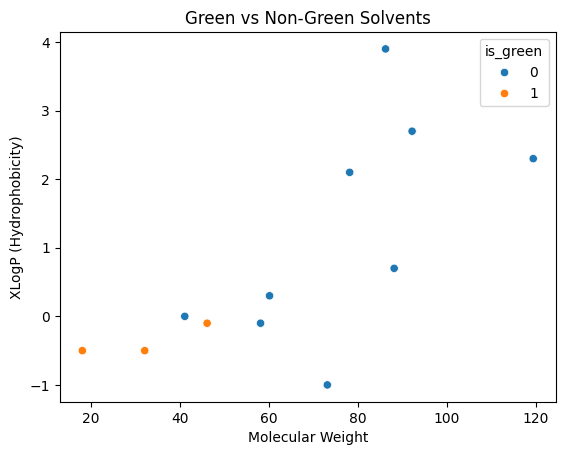

In [11]:
sns.scatterplot(data=df, x="MolecularWeight", y="XLogP", hue="is_green")
plt.title("Green vs Non-Green Solvents")
plt.xlabel("Molecular Weight")
plt.ylabel("XLogP (Hydrophobicity)")
plt.show()

#### 11.Sustainability Ranking

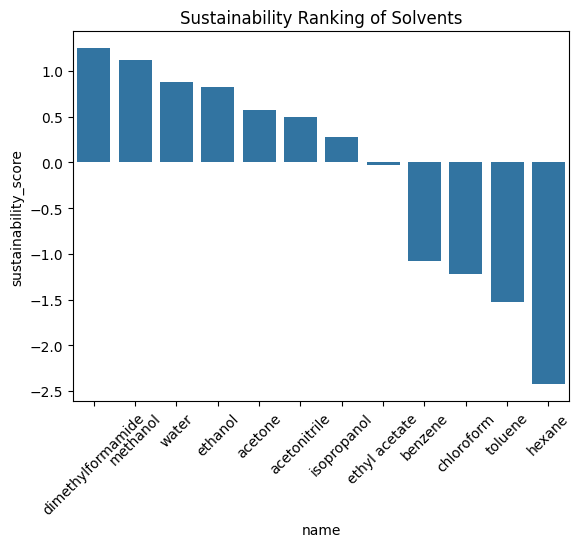

In [12]:
df_sorted = df.sort_values(by="sustainability_score", ascending=False)

sns.barplot(data=df_sorted, x="name", y="sustainability_score")
plt.title("Sustainability Ranking of Solvents")
plt.xticks(rotation=45)
plt.show()

#### 12. Case Study — Benzene vs Ethanol

In [13]:
comparison = df[df["name"].isin(["benzene", "ethanol"])]

comparison[[
    "name", "XLogP", "polarity_score",
    "solubility_score", "persistence_score",
    "toxicity_score", "sustainability_score"
]]

,name,XLogP,polarity_score,solubility_score,persistence_score,toxicity_score,sustainability_score
1,ethanol,-0.1,0.1,0.1,-0.1,-0.1,0.825
6,benzene,2.1,-2.1,-2.1,2.1,2.1,-1.075


#### 13. Case Study Visualization

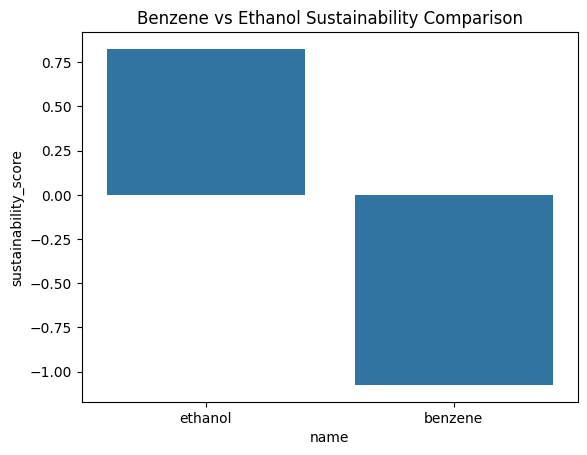

In [14]:
sns.barplot(data=comparison, x="name", y="sustainability_score")
plt.title("Benzene vs Ethanol Sustainability Comparison")
plt.show()

#### 14. Group Analysis

In [15]:
df.groupby("is_green")["sustainability_score"].mean()

is_green
0   -0.408333
1    0.941667
Name: sustainability_score, dtype: float64